#### Question 1
Program the Heavyball Method

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
f = lambda x,y: 100*(y-x**2)**2+(1-x)**2
Df = lambda x,y: np.array([400*x**3-400*x*y-2+2*x,
                           200*y - 200*x**2])
D2g = lambda x,y: np.array([[1200*x**2 - 400*y +2, -400*x],
                            [-400*x, 200]])

In [11]:
from matplotlib.colors import LogNorm  # useful for visualizing this function

def plot_path(path, func, title, window=[-4.5,4.5,-4.5,4.5], contours=np.logspace(-2,6,100), skip=1):
    '''Plots path defined in (N,2) array "path" on a contour plot of "func" in window "window"'''
    plt.figure(figsize=(5,5),dpi=150)
    X = np.linspace(window[0],window[1],300)
    Y = np.linspace(window[2],window[3],300)
    Xmesh, Ymesh = np.meshgrid(X,Y)
    Z = func(Xmesh,Ymesh)
    CS = plt.contourf(Xmesh, Ymesh, Z, contours, cmap='jet', norm = LogNorm())
    # contourf fills the colors. blue is lower value, red is higher value
     
    plt.axis(window)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)

    if path is not None:
        for i in range(path.shape[0]-1): # iterate through steps
            if i%skip==0:
                # only plot arrows every "skip" iterations
                plt.arrow(path[i,0],path[i,1],path[i+1,0]-path[i,0],path[i+1,1]-path[i,1],
                          color='k',length_includes_head=True)
    plt.show() 

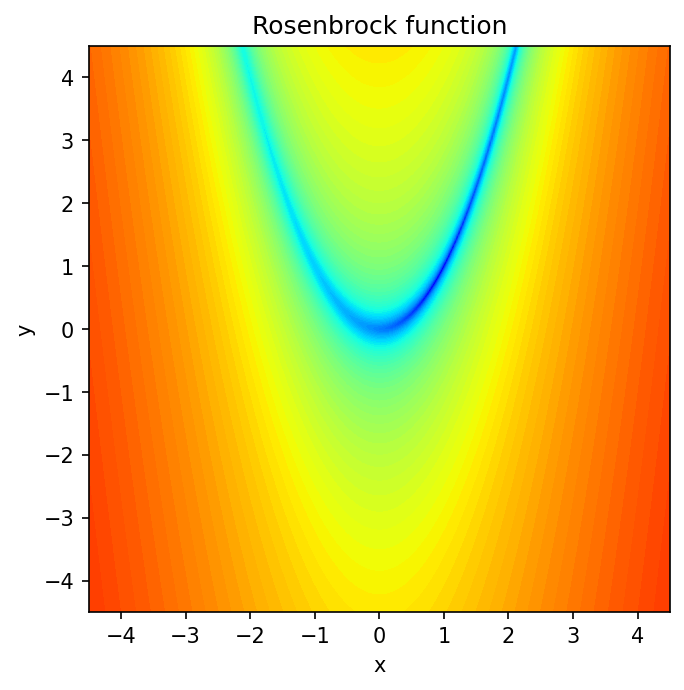

In [12]:
plot_path(None,f,'Rosenbrock function')

In [37]:
D2g(1,1)
eigs, _ = np.linalg.eigh(D2g(1,1))
maxval = eigs[1]
minval = eigs[0]
for i in range(1000):
    x = np.random.uniform(-4.5,4.5,2) # generate a random point
    H = D2g(x[0],x[1])                # and evaluate the Hessian there
    tmp_eigs, _ = np.linalg.eigh(H)
    if tmp_eigs[1]>maxval:                # if eigenvalues larger or smaller, choose those
        maxval = tmp_eigs[1]
    if tmp_eigs[0]<minval:
        minval = tmp_eigs[0]
        
print('Maximum eigenvalue :',maxval,'\nMinimum eigenvalue :',minval)

Maximum eigenvalue : 26034.313774842354 
Minimum eigenvalue : -1585.8887387892491


In [38]:
%%time
x = np.array([-3,-1])
path = [x]
tol = 1e-8
beta = (np.sqrt(maxval)-np.sqrt(eigs[0]))**2/(np.sqrt(maxval)+np.sqrt(eigs[0]))**2  
print('beta = ',beta)
alpha = 4/(np.sqrt(eigs[0])+np.sqrt(maxval))**2                                      
print('alpha = ',alpha)
max_steps = 20000
dx = Df(x[0],x[1])
pk = dx*0      # first update is just gradient descent
i=0
while np.linalg.norm(dx)>tol and i<max_steps:
    pk = -alpha*dx + beta*pk
    xnew = x + pk
    path.append(xnew)
    x = xnew
    i += 1
    dx = Df(x[0],x[1])

path = np.array(path)
print(f'After {i} iterations, approximate minimum is {f(x[0],x[1])} at {x}')

beta =  0.9844555861978365
alpha =  0.00015244689471792422
After 3031 iterations, approximate minimum is 8.39746058177569e-17 at [1.00000001 1.00000002]
CPU times: user 74.4 ms, sys: 15.8 ms, total: 90.2 ms
Wall time: 72.8 ms


#### Question 2

a) Compute optimal solution by solving normal equation

In [81]:
data = pd.read_csv('CaCovidInfMarch24toMidJuly.txt')
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
linear = LinearRegression()
poly = PolynomialFeatures(degree = 2)

In [82]:
X_train = data[0:90]
X_valid = data[90:120]

In [83]:
X_poly = poly.fit_transform(X_train)
linear.fit(X_poly,)